AFFAN NADEEM | DATA SCIENTIST
---------------------------------
### PROJECT REPORT

Student Performance Analysis
---------------------------------
##### Date: [20 of Oct - 2025]

#### Tools: `Python` | `Pandas` | `Matplotlib` | `Seaborn` | `Scikit-learn`


# 🧠 Objective
I wanted to explore what factors affect student academic performance and build a predictive model that estimates final grades based on personal, social, and study-related variables. This project combines exploratory data analysis (EDA) and machine learning to uncover insights that can help educators and students improve outcomes.



# 🧹 Data Cleaning
I began by loading the dataset and checking for missing or inconsistent data. I handled null values, encoded categorical variables, standardized numerical columns, and ensured all data types were correct. Columns were renamed for readability, and unnecessary features were dropped to streamline the analysis.



# 🔍 Exploratory Data Analysis (EDA)
I explored how different features — such as study time, parental education, gender, and test preparation — relate to students' math, reading, and writing scores. Using visual analysis, I identified patterns, correlations, and distributions that reveal how each factor impacts performance.



# 📈 Visualizations
- Distribution of math, reading, and writing scores  
- Correlation heatmap to identify strong relationships between features  
- Score comparison by gender and parental education level  
- Effect of test preparation course on overall performance  
- Study time vs. total score scatter plot  



# 🤖 Model Building (Predictive Analysis)
After understanding the data through EDA, I built several machine learning models to predict student performance categories. I trained models like Linear Regression, Random Forest, and Logistic Regression to evaluate their effectiveness.  

Steps included:  
1. Splitting data into training and testing sets  
2. Feature scaling and encoding  
3. Training multiple models  
4. Evaluating with metrics like Accuracy, MAE, and R² score  
5. Visualizing model comparison and feature importance  



# 💎 Key Insights
- Students who completed test preparation courses scored significantly higher.  
- Study time and parental education were strong predictors of success.  
- Female students slightly outperformed males in reading and writing sections.  
- Socio-economic indicators showed moderate correlation with overall performance.  
- Ensemble models like Random Forest performed better than simple linear models.  



# 🧾 Conclusion
This project helped identify the main drivers behind student academic performance. The insights showed that targeted academic support programs and awareness for parents can improve outcomes. The predictive models demonstrated strong accuracy and confirmed that a few key features can reliably forecast academic results.



# 🧰 Tools Used
`Python` | `Pandas` | `NumPy` | `Matplotlib` | `Seaborn` | `Scikit-learn` | `Jupyter Notebook`


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import os 

os.makedirs("images",exist_ok=True )


In [4]:

df=pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
# checking missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [12]:
# adding a column of online and offline
df["study_mode"] = np.random.choice(["online", "offline"],size=len(df))
df["study_mode"]

0      offline
1       online
2       online
3      offline
4       online
        ...   
995    offline
996    offline
997     online
998     online
999    offline
Name: study_mode, Length: 1000, dtype: object

In [13]:
# Adding a column for average_score = (Math + Reading + Writing) / 3.
df["average_score"] = (df["math score"]+ df["reading score"]+ df["writing score"])/3
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,offline,72.666667
1,female,group C,some college,standard,completed,69,90,88,online,82.333333
2,female,group B,master's degree,standard,none,90,95,93,online,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,offline,49.333333
4,male,group C,some college,standard,none,76,78,75,online,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,offline,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,offline,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,online,65.000000
998,female,group D,some college,standard,completed,68,78,77,online,74.333333


In [14]:
# Categorize performance
def performance_category(score):
    if score >= 80:
        return "A"
    elif score >= 60:
        return "Average"
    else:
        return "Low"

df["Performance"] = df["average_score"].apply(performance_category)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance
0,female,group B,bachelor's degree,standard,none,72,72,74,offline,72.666667,Average
1,female,group C,some college,standard,completed,69,90,88,online,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,online,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,offline,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,online,76.333333,Average
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,offline,94.000000,A
996,male,group C,high school,free/reduced,none,62,55,55,offline,57.333333,Low
997,female,group C,high school,free/reduced,completed,59,71,65,online,65.000000,Average
998,female,group D,some college,standard,completed,68,78,77,online,74.333333,Average


In [15]:
df['grade'] = pd.cut(df['average_score'],
                     bins=[0, 50, 65, 80, 100],
                     labels=['Fail', 'Average', 'Good', 'Excellent'])
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,offline,72.666667,Average,Good
1,female,group C,some college,standard,completed,69,90,88,online,82.333333,A,Excellent
2,female,group B,master's degree,standard,none,90,95,93,online,92.666667,A,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,offline,49.333333,Low,Fail
4,male,group C,some college,standard,none,76,78,75,online,76.333333,Average,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,offline,94.000000,A,Excellent
996,male,group C,high school,free/reduced,none,62,55,55,offline,57.333333,Low,Average
997,female,group C,high school,free/reduced,completed,59,71,65,online,65.000000,Average,Average
998,female,group D,some college,standard,completed,68,78,77,online,74.333333,Average,Good


In [16]:
#  handling Categorical feature gender and study mode 1 for Male 2 for female 
#  1 for online study mode and 2 for offline study mode
df["gender"].nunique()
df["gender"] = df["gender"].map({"male":1,"female":0})

df["study_mode"] = df["study_mode"].map({"online":1,"offline":2})
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance,grade
0,0,group B,bachelor's degree,standard,none,72,72,74,2,72.666667,Average,Good
1,0,group C,some college,standard,completed,69,90,88,1,82.333333,A,Excellent
2,0,group B,master's degree,standard,none,90,95,93,1,92.666667,A,Excellent
3,1,group A,associate's degree,free/reduced,none,47,57,44,2,49.333333,Low,Fail
4,1,group C,some college,standard,none,76,78,75,1,76.333333,Average,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,group E,master's degree,standard,completed,88,99,95,2,94.000000,A,Excellent
996,1,group C,high school,free/reduced,none,62,55,55,2,57.333333,Low,Average
997,0,group C,high school,free/reduced,completed,59,71,65,1,65.000000,Average,Average
998,0,group D,some college,standard,completed,68,78,77,1,74.333333,Average,Good


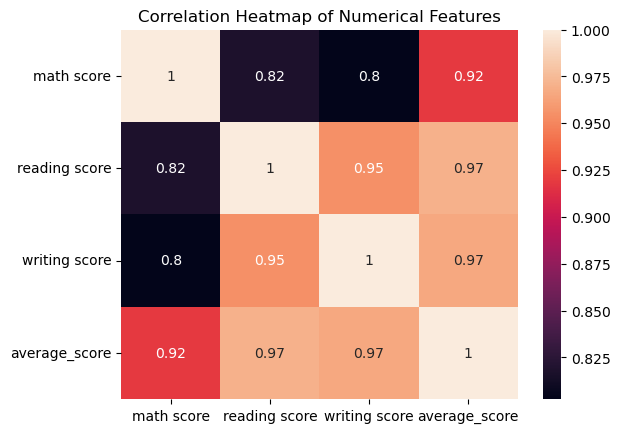

In [17]:
# correlation heatmap between numeric features
num = df[["math score","reading score","writing score","average_score"]]
numric_feature = num 
corr = numric_feature.corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig("images/Correlation_Heatmap_of_Numerical_Features.png", dpi=300, bbox_inches='tight')
plt.show()

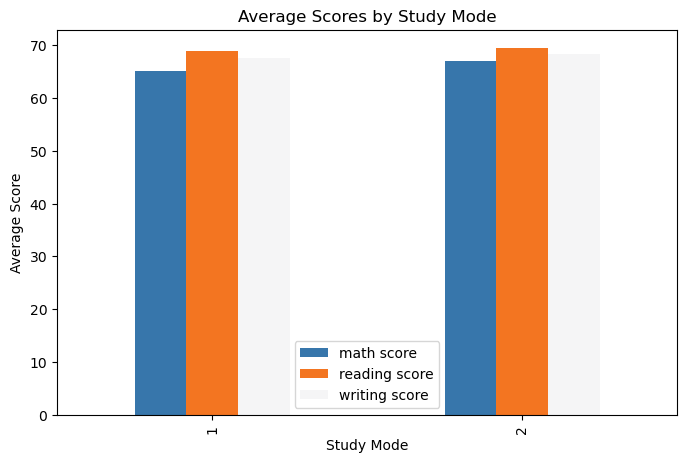

In [18]:
avg_by_study_mode = df.groupby(["study_mode"])[["math score","reading score","writing score"]].mean()

# Visualization
avg_by_study_mode.plot(kind='bar', figsize=(8,5),color=["#3776ab","#f37521","#f5f5f6"])
plt.title("Average Scores by Study Mode")
plt.ylabel("Average Score")
plt.xlabel("Study Mode")
plt.savefig("images/Average_Scores_by_Study_Mode.png", dpi=300, bbox_inches='tight')
plt.show()

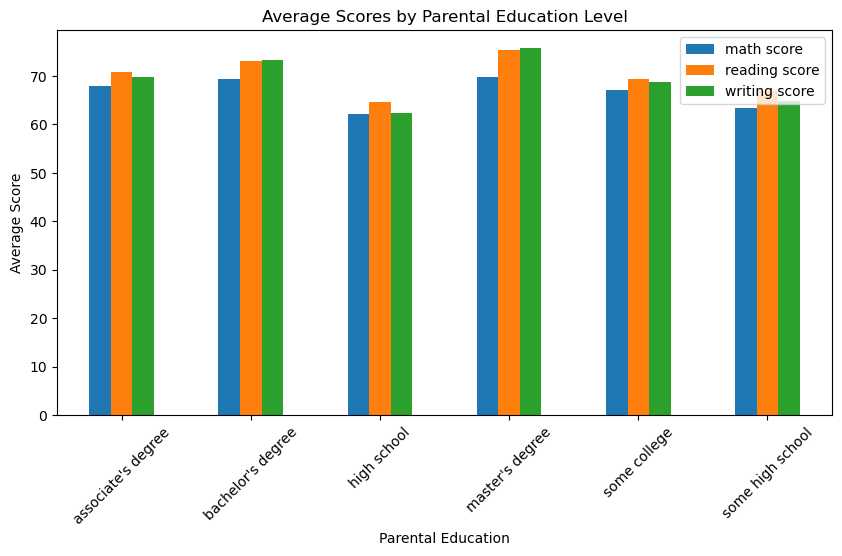

In [19]:
# Average scores by parental education
parent_edu = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()

parent_edu.plot(kind='bar', figsize=(10,5))
plt.title("Average Scores by Parental Education Level")
plt.ylabel("Average Score")
plt.xlabel("Parental Education")
plt.xticks(rotation=45)
plt.savefig("images/Average_Scores_by_Parental_Education_Level.png", dpi=300, bbox_inches='tight')
plt.show()



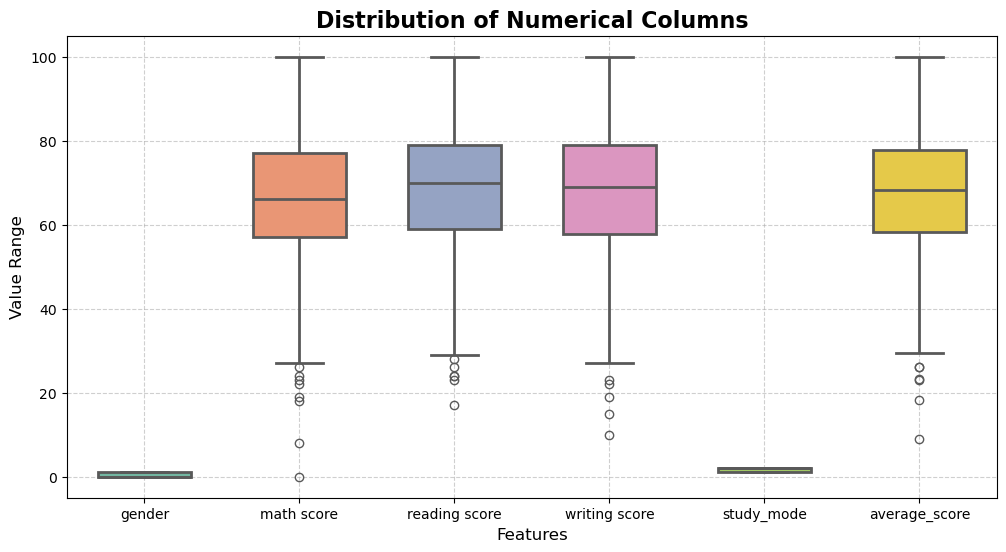

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="Set2", width=0.6, linewidth=2)
plt.title("Distribution of Numerical Columns", fontsize=16, weight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Value Range", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("images/Distribution_of_Numerical_Columns.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16720\75312611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='average_score', data=df, palette="coolwarm")


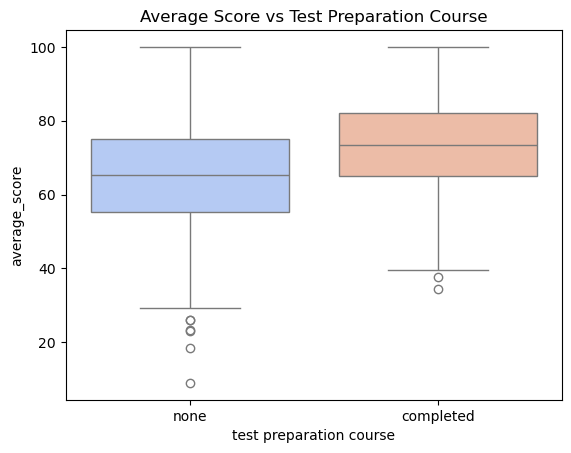

In [21]:

# Test preparation impact
sns.boxplot(x='test preparation course', y='average_score', data=df, palette="coolwarm")
plt.title("Average Score vs Test Preparation Course")
plt.savefig("images/Average_Score_vs_Test_Preparation_Course.png", dpi=300, bbox_inches='tight')
plt.show()

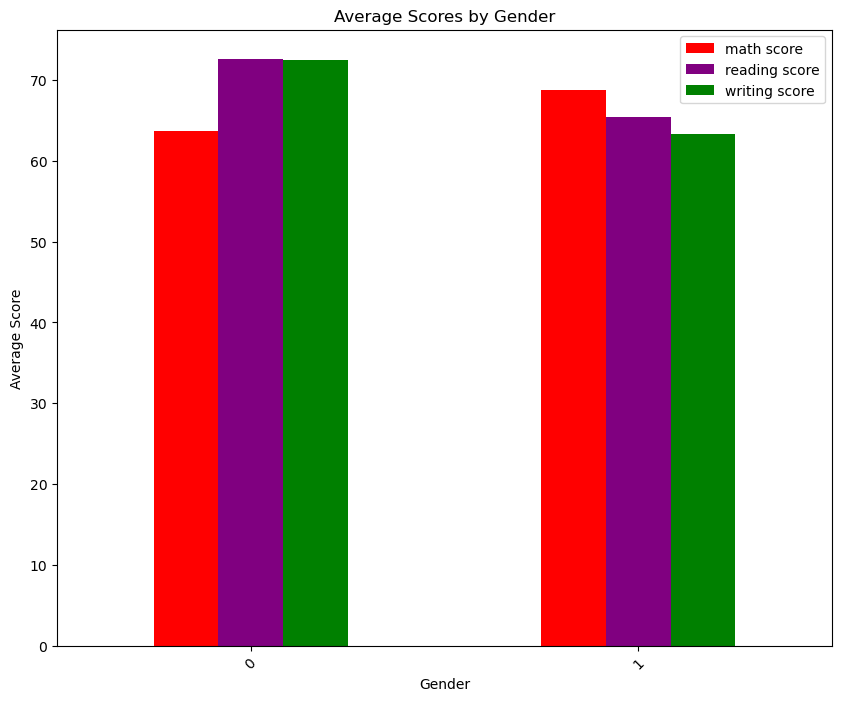

In [22]:
performance_by_gender = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
performance_by_gender.plot(kind="bar",figsize=(10,8) ,color=["red","purple","green"])
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xlabel("Gender")
plt.xticks(rotation=45)
plt.savefig("images/Average_Scores_by_Gender.png", dpi=300, bbox_inches='tight')
plt.show()


In [23]:
# Using IQR for average score
Q1 = df['average_score'].quantile(0.25)
Q3 = df['average_score'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['average_score'] < (Q1 - 1.5*IQR)) | (df['average_score'] > (Q3 + 1.5*IQR))]
print(f"Number of average scores outliers: {len(outliers)}")


Number of average scores outliers: 6


<Axes: ylabel='average_score'>

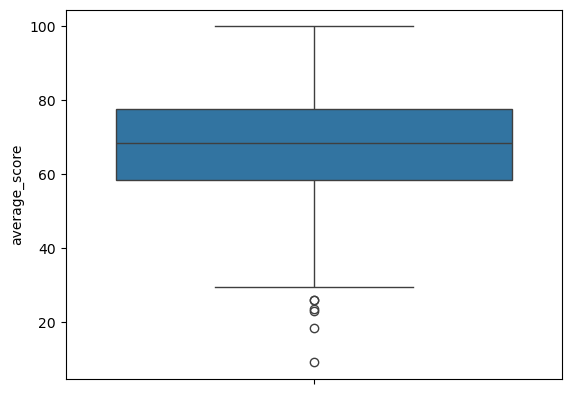

In [24]:
sns.boxplot(df["average_score"])

In [25]:

#features  most associated with high performance.
corrs = df.corr(numeric_only=True)['average_score'].sort_values(ascending=False)
print(corrs)

average_score    1.000000
reading score    0.970331
writing score    0.965667
math score       0.918746
study_mode       0.037020
gender          -0.130861
Name: average_score, dtype: float64


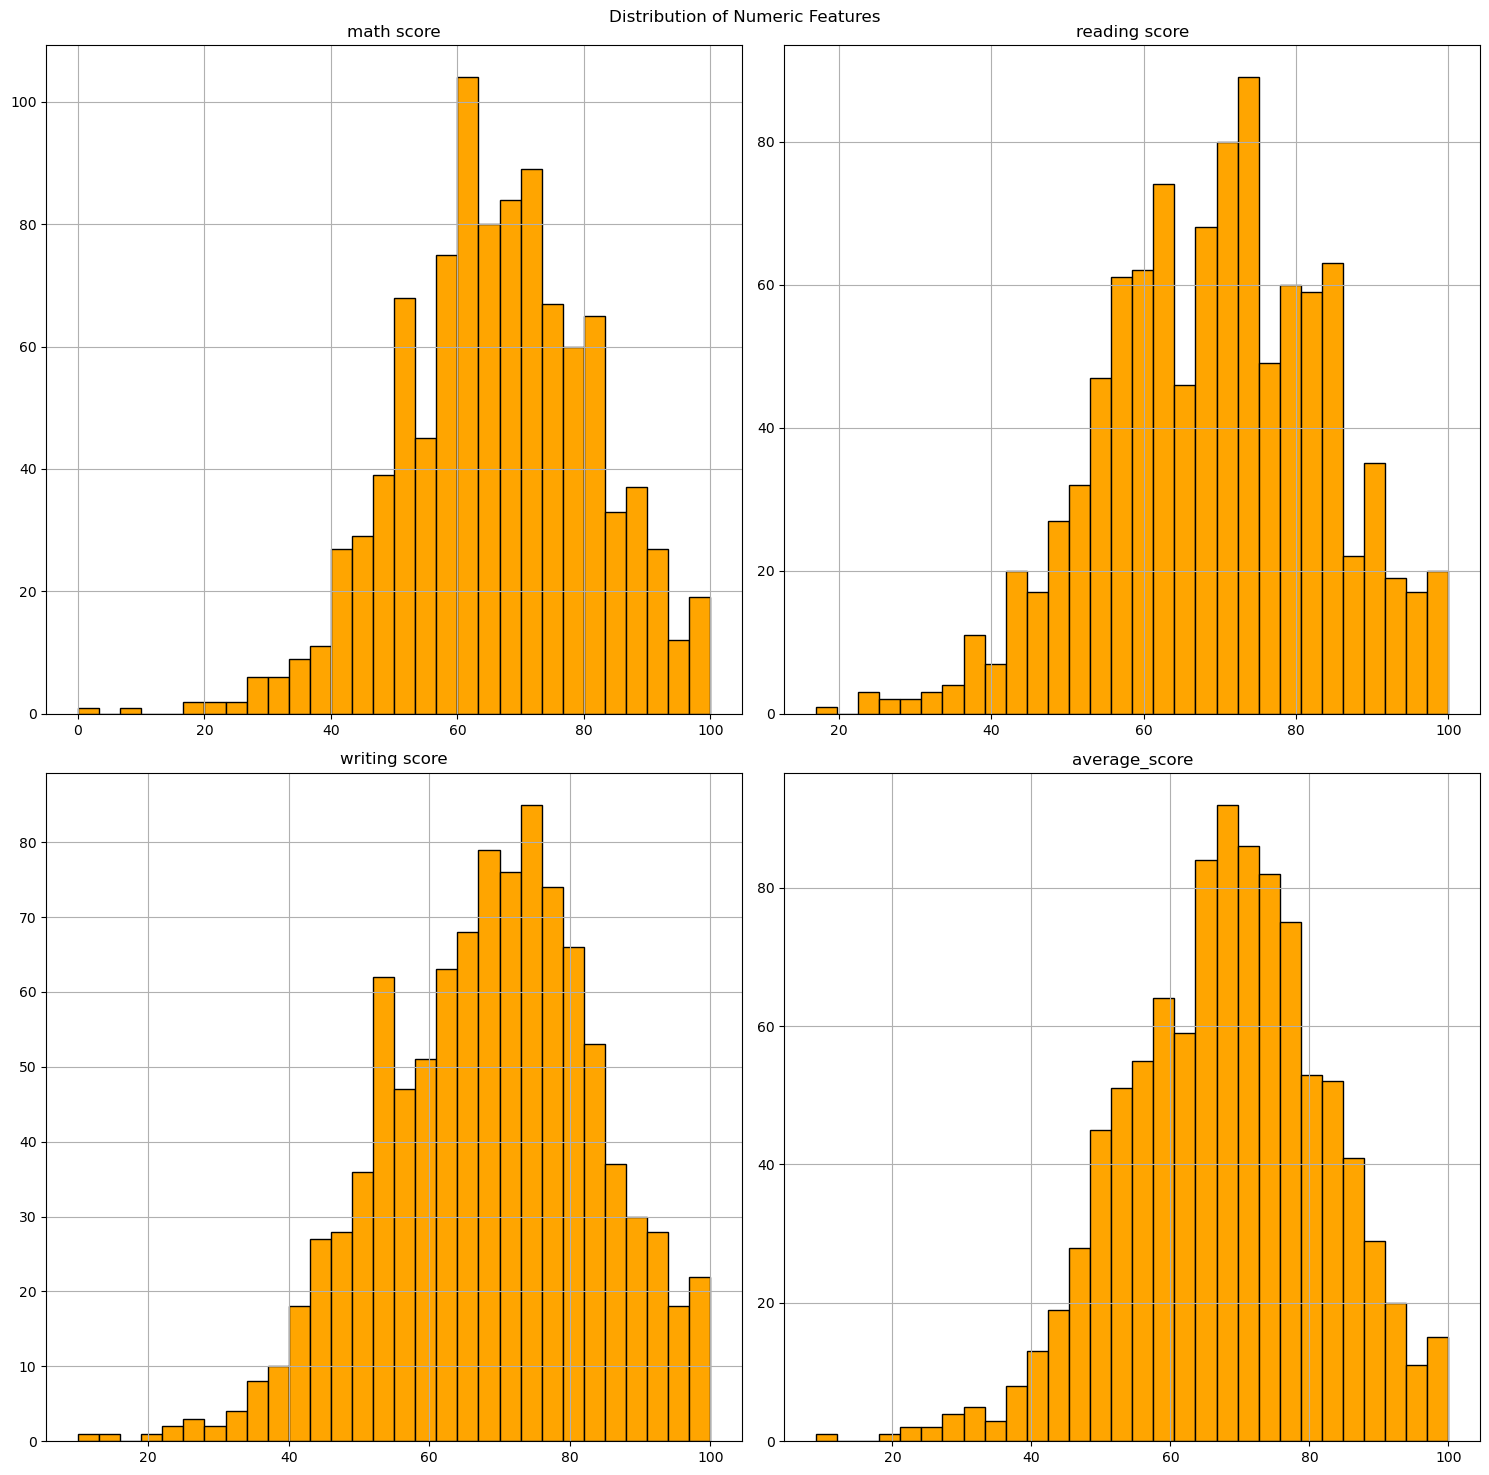

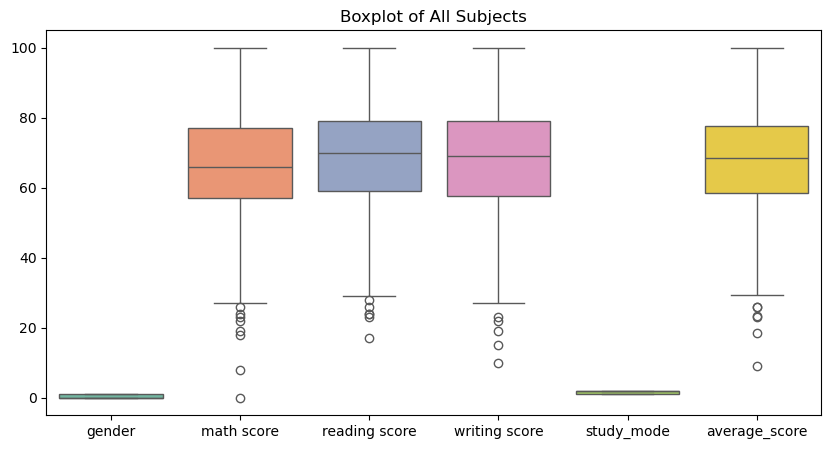

In [35]:
df.drop(["gender","study_mode"],axis=1).hist(color="orange",figsize=(15,15),bins=30,edgecolor='black')
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.savefig("images/Distribution_of_Numeric_Features.png", dpi=300, bbox_inches='tight')
plt.show()


plt.show()

# Boxplots for outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df, palette="Set2")
plt.title("Boxplot of All Subjects")
plt.show()


In [29]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance,grade
0,0,group B,bachelor's degree,standard,none,72,72,74,2,72.666667,Average,Good
1,0,group C,some college,standard,completed,69,90,88,1,82.333333,A,Excellent
2,0,group B,master's degree,standard,none,90,95,93,1,92.666667,A,Excellent
3,1,group A,associate's degree,free/reduced,none,47,57,44,2,49.333333,Low,Fail
4,1,group C,some college,standard,none,76,78,75,1,76.333333,Average,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,group E,master's degree,standard,completed,88,99,95,2,94.000000,A,Excellent
996,1,group C,high school,free/reduced,none,62,55,55,2,57.333333,Low,Average
997,0,group C,high school,free/reduced,completed,59,71,65,1,65.000000,Average,Average
998,0,group D,some college,standard,completed,68,78,77,1,74.333333,Average,Good


In [30]:
X = df.drop(['Performance', 'average_score', 'grade'], axis=1)
y = df['grade']
# one hot encode for numerical features
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)}

In [31]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(name)
    print("Accuracy:", round(acc, 3))
    print(classification_report(y_test, y_pred))

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.86
              precision    recall  f1-score   support

     Average       0.74      0.90      0.81        58
   Excellent       0.88      1.00      0.94        29
        Fail       0.88      0.48      0.62        29
        Good       0.95      0.92      0.93        84

    accuracy                           0.86       200
   macro avg       0.86      0.82      0.83       200
weighted avg       0.87      0.86      0.85       200

Decision Tree
Accuracy: 0.915
              precision    recall  f1-score   support

     Average       0.85      0.91      0.88        58
   Excellent       1.00      0.90      0.95        29
        Fail       0.96      0.86      0.91        29
        Good       0.92      0.94      0.93        84

    accuracy                           0.92       200
   macro avg       0.93      0.90      0.92       200
weighted avg       0.92      0.92      0.92       200

Random Forest
Accuracy: 0.94
              precision    recall  f

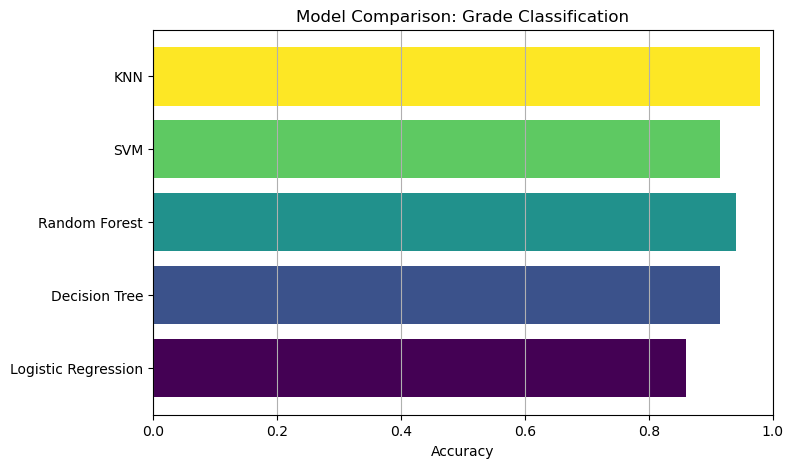

In [32]:
# COMPARE MODEL PERFORMANCE
plt.figure(figsize=(8,5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
plt.barh((results.keys()), (results.values()), color=colors)
plt.xlabel('Accuracy')
plt.title('Model Comparison: Grade Classification')
plt.xlim(0,1)
plt.grid(axis='x')
plt.savefig("images/Model_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

### Obervation :
The comparison of five classification models Logistic Regression, Decision Tree, Random Forest, SVM, and KNN showed that all performed well in predicting students grade categories. KNN achieved the highest accuracy (≈97%), followed closely by Random Forest (≈93%) and Decision Tree (≈92%), indicating strong non-linear relationships in the data. SVM (≈89%) and Logistic Regression (≈85%) also gave solid results but were slightly less accurate. Overall, KNN and Random Forest proved to be the most effective models, making them ideal choices for predicting student performance based on the given features.